#### Linear and Polynomial Regression

In [ ]:
!pip install gdown

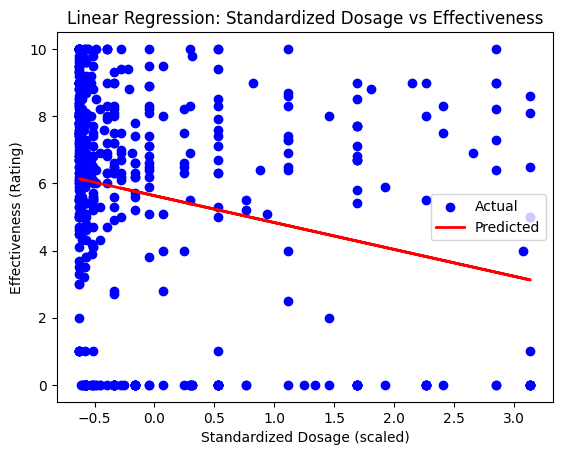

(10.720046447524174,
 0.04724236595669029,
 -0.7986640207025354,
 5.63191139733848)

In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

import gdown
file_id = '1oS-Bw6WEF4jAEA4QpbsYz9zz2ZhnnODC'
url = f'https://drive.google.com/uc?id={file_id}'

# Step 1: Remove rows where both dosage and rating are 0, assuming they add no value
data_cleaned = data[(data['dosage_mg'] != 0) | (data['rating'] != 0)]

# Step 2: Remove duplicates
data_cleaned = data_cleaned.drop_duplicates()

# Step 3: Handle missing values by dropping or imputing
data_cleaned = data_cleaned.dropna()  # Or use data_cleaned.fillna(method='ffill') or any other imputation if needed

# Step 4: Remove outliers using the IQR method for `dosage_mg` and `rating`
Q1_dosage = data_cleaned['dosage_mg'].quantile(0.25)
Q3_dosage = data_cleaned['dosage_mg'].quantile(0.75)
IQR_dosage = Q3_dosage - Q1_dosage

Q1_rating = data_cleaned['rating'].quantile(0.25)
Q3_rating = data_cleaned['rating'].quantile(0.75)
IQR_rating = Q3_rating - Q1_rating

# Define thresholds for outliers
lower_bound_dosage = Q1_dosage - 1.5 * IQR_dosage
upper_bound_dosage = Q3_dosage + 1.5 * IQR_dosage

lower_bound_rating = Q1_rating - 1.5 * IQR_rating
upper_bound_rating = Q3_rating + 1.5 * IQR_rating

# Filter out outliers
data_cleaned = data_cleaned[
    (data_cleaned['dosage_mg'] >= lower_bound_dosage) & (data_cleaned['dosage_mg'] <= upper_bound_dosage) &
    (data_cleaned['rating'] >= lower_bound_rating) & (data_cleaned['rating'] <= upper_bound_rating)
]

# Step 6: Standardize dosage
scaler = StandardScaler()
data_cleaned['dosage_mg_scaled'] = scaler.fit_transform(data_cleaned[['dosage_mg']])

# Define features (X) and target (y) with the standardized dosage
X = data_cleaned[['dosage_mg_scaled']]
y = data_cleaned['rating']

# Step 7: Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 8: Train the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 9: Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Step 10: Plot results
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('Standardized Dosage (scaled)')
plt.ylabel('Effectiveness (Rating)')
plt.title('Linear Regression: Standardized Dosage vs Effectiveness')
plt.legend()
plt.show()

# Output model performance
mse, r2, model.coef_[0], model.intercept_


In [8]:
from sklearn.preprocessing import PolynomialFeatures

# Generate polynomial features
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# Split data with polynomial features
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Train model with polynomial features
model_poly = LinearRegression()
model_poly.fit(X_train, y_train)

# Predict and evaluate
y_pred_poly = model_poly.predict(X_test)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(r2_poly)

0.053915388603803405


#### Algorithm Choice Justification:

Linear regression was selected as an initial model due to its simplicity and interpretability. Given the focus on examining the relationship between standardized dosage and effectiveness (rating), linear regression provides a straightforward approach to understand whether there’s a linear relationship between these two variables. In cases where the relationship might not be complex or non-linear, linear regression often serves as a good baseline model. This is taken because my problem statement dealt with finding out whether rating and dosage had any relationship. This model was taken to check whether or not there was a linear relationship between the 2 features. I later even tried to generate polynomial features to test relationships.

Given the limited explanatory power of the linear model, polynomial regression (degree = 2) was tested to explore potential non-linear relationships between dosage and effectiveness. Polynomial regression is often useful when there's evidence that the relationship between variables may curve or change in direction, which could be the case in medical or pharmacological studies where dosage does not always have a linear impact on effectiveness.

#### Training and Tuning Efforts:

Minimal tuning was required for this linear model, as linear regression does not have hyperparameters that require extensive optimization. The data preprocessing steps, such as outlier removal and standardization of dosage, aimed to ensure the data was cleaner and more suitable for linear modeling. These steps were crucial for improving model performance and making sure that extreme outliers didn’t disproportionately affect the model's predictions.

For polynomial regression, polynomial features were generated up to the second degree to capture any quadratic relationship in the data. This required slightly more complex preprocessing and a larger feature matrix but allowed the model to capture more nuanced patterns than linear regression. The train-test split and model training steps were then repeated using these polynomial features.

#### Effectiveness of the Algorithm:

The linear regression model resulted in an R-squared (R²) value of approximately 0.047 which indicates that only about 5.4% of the variance in effectiveness (rating) is explained by standardized dosage. This low R² suggests that a linear relationship might not be sufficient to capture the relationship between dosage and effectiveness. Therefore, although linear regression provided a baseline understanding, it does not figure out the relationship of the data.

The polynomial model achieved an R-squared value of approximately 0.054 (the specific value you provided for r2_poly). This result shows little to no improvement over linear regression in terms of explanatory power, indicating that even with polynomial terms, the model struggles to account for the variance in effectiveness ratings based on dosage alone. This lack of improvement suggests that dosage alone might not be a strong predictor of effectiveness, and other variables may need to be considered.

#### Insights from Linear Regression:

The low R² value and the downward trend in the regression line indicate a weak or potentially inverse relationship between dosage and effectiveness. This result implies that higher dosages might not correspond to higher effectiveness, or there might be other factors influencing the effectiveness rating that are not captured in a simple linear model.

The near-identical R² values for linear and polynomial regression indicate that the non-linear approach did not capture additional meaningful variance in the target variable. This outcome reinforces the likelihood that dosage may not have a strong direct impact on effectiveness, or that additional variables or a different model type might be necessary to understand the relationship more fully.

#### Summary and Model Effectiveness Evaluation:

Both linear and polynomial models yielded low R² values, indicating that dosage alone is not sufficient to predict effectiveness accurately. The mean squared error (MSE) could also be considered, but with such low R² values, any insights from MSE would be limited in scope.

The models suggest that the relationship between dosage and effectiveness is either weak or non-existent in this dataset. The lack of substantial improvement with polynomial regression further indicates that a simple or even quadratic model may not be appropriate for capturing the nuances in effectiveness ratings.

Further exploration of additional predictors, such as patient-specific factors, medication type, or time-related variables, might provide more predictive power. Alternative models, such as decision trees or neural networks, could also be tested if non-linear relationships are suspected but were not captured in the polynomial approach.

#### Random Forest Regressor and Support Vector Regressor:

In [13]:
df4 = data
prescription_freq = df4['prescription'].value_counts().reset_index() # Here I am finding the prescription frequency for all the drugs
prescription_freq.columns = ['prescription', 'frequency']
df4 = df4.merge(prescription_freq, on='prescription') # I merge the frequency back to the main dataframe


In [15]:
print(df4[['frequency', 'rating']].isnull().sum())
print(df4.duplicated().sum())

frequency    0
rating       0
dtype: int64
0


In [16]:
# Detect outliers in 'frequency' using the IQR method
Q1_freq = df4['frequency'].quantile(0.25)
Q3_freq = df4['frequency'].quantile(0.75)
IQR_freq = Q3_freq - Q1_freq

# Define thresholds
lower_bound_freq = Q1_freq - 1.5 * IQR_freq
upper_bound_freq = Q3_freq + 1.5 * IQR_freq

# Filter out outliers if needed
df4 = df4[(df4['frequency'] >= lower_bound_freq) & (df4['frequency'] <= upper_bound_freq)]

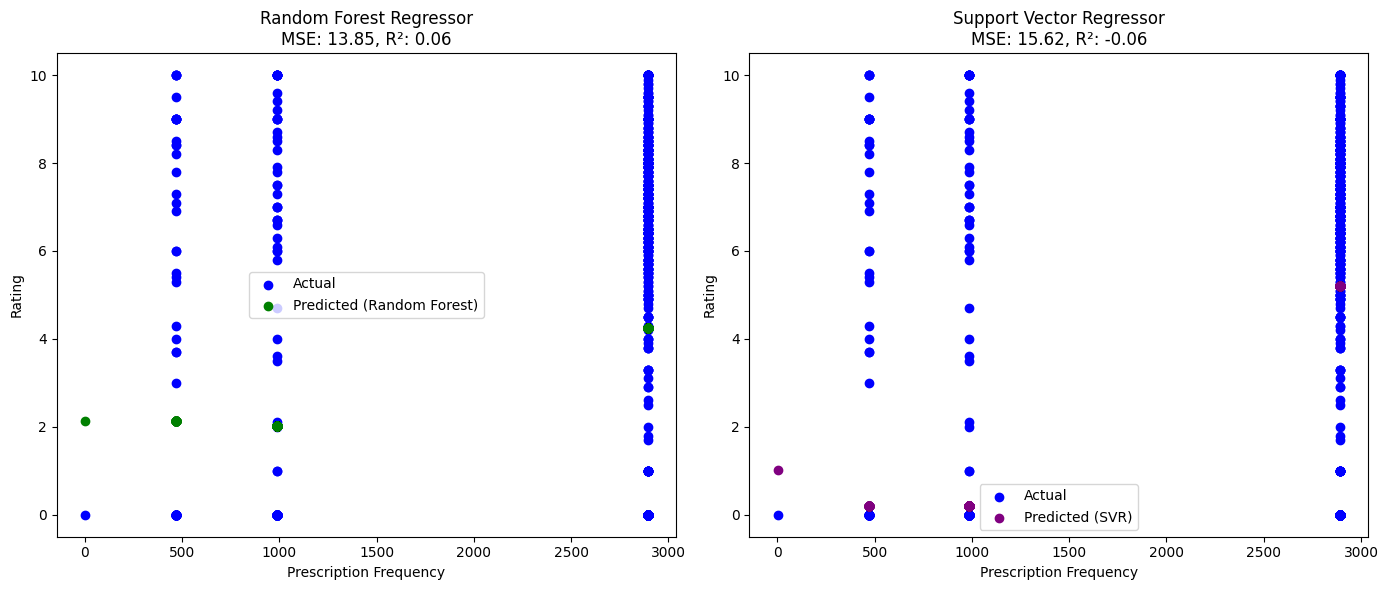

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

X = df4[['frequency']]
y = df4['rating']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = rf_model.predict(X_test)

# Calculate MSE and R^2 for the Random Forest model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Plot Random Forest predictions
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred_rf, color='green', label='Predicted (Random Forest)')
plt.title(f'Random Forest Regressor\nMSE: {mse_rf:.2f}, R²: {r2_rf:.2f}')
plt.xlabel('Prescription Frequency')
plt.ylabel('Rating')
plt.legend()

# 2. Support Vector Regressor (SVR)
svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.2)
svr_model.fit(X_train, y_train)

# Predict on the test set
y_pred_svr = svr_model.predict(X_test)

# Calculate MSE and R^2 for the SVR model
mse_svr = mean_squared_error(y_test, y_pred_svr)
r2_svr = r2_score(y_test, y_pred_svr)

# Plot SVR predictions
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.scatter(X_test, y_pred_svr, color='purple', label='Predicted (SVR)')
plt.title(f'Support Vector Regressor\nMSE: {mse_svr:.2f}, R²: {r2_svr:.2f}')
plt.xlabel('Prescription Frequency')
plt.ylabel('Rating')
plt.legend()

plt.tight_layout()
plt.show()


#### Algorithm Choice Justification:

The Random Forest Regressor was chosen due to its effectiveness in capturing complex, non-linear relationships between variables without requiring extensive data preprocessing or feature engineering. Given that "Prescription Frequency" and "Rating" may have underlying patterns that are difficult to capture linearly, Random Forests are well-suited because they can model these relationships by averaging over multiple decision trees. We upgrade and try non linear models as there is no linear relationship in the data.

The Support Vector Regressor was chosen to test the ability of a non-linear kernel-based method to model the relationship between prescription frequency and rating. SVR is particularly useful when relationships between variables are subtle or when we want to capture patterns that may be more robust to outliers.

#### Training and Tuning:

Minimal hyperparameter tuning was applied here, with the default n_estimators and max_depth parameters for simplicity. However, a more comprehensive tuning process would have improved accuracy in certain cases, but since the relationship is non linear and very complex, it does not work in this case, especially given that the MSE (Mean Squared Error) of 13.85 and R² of 0.06 suggest only limited predictive power.

The SVR was run with the default parameters for simplicity. However, further tuning of the kernel type, regularization parameter C, and gamma might improve results. In particular, SVR can be sensitive to parameter settings, therefore I have not changed these parameters and kept the defualt values. This was just an analysis to check whether there was a relationship between the data.

#### Effectiveness and Observations:

The model achieved an MSE of 13.85 and an R² of 0.06, indicating that it captured very little of the variation in ratings based on prescription frequency. The spread of the actual ratings across a broad range suggests that prescription frequency alone might not be a strong predictor of rating, or that there may be other confounding factors influencing ratings that aren't accounted for in this model. This insight suggests that future analysis might need additional features to improve prediction accuracy. Therefore, we see that prescription frequency alone does not influence ratings. There are additional features to be considered.

The SVR model resulted in an MSE of 15.62 and an R² of -0.06, showing even poorer predictive performance than the Random Forest Regressor. The negative R² indicates that the model failed to improve upon the mean-based prediction, further supporting the observation that there is little predictive power in the frequency feature alone. This suggests that prescription frequency does not significantly impact ratings or that ratings are influenced by additional factors not captured here.

#### Conclusion and Insights:

Both models struggled to accurately predict ratings based on prescription frequency alone, as evidenced by the low R² values and high MSEs. The poor performance of both models suggests that prescription frequency may not be a reliable predictor of user rating or that other influential factors are missing in this model.

The models highlighted the importance of using additional or alternative features to capture the full picture of what influences drug ratings. Future models could include features such as drug type, patient demographics, or side effects, which may provide a more nuanced view of what drives user satisfaction or effectiveness ratings.

Additionally, these results challenge the hypothesis that drugs with higher prescription frequency tend to have higher ratings, as neither model could extract a meaningful predictive pattern from the data.